In [3]:
import numpy as np

fish_length = [25.4, 26.3, 26.5, 29.0, 29.0, 29.7, 29.7, 30.0, 30.0, 30.7, 31.0, 31.0, 
                31.5, 32.0, 32.0, 32.0, 33.0, 33.0, 33.5, 33.5, 34.0, 34.0, 34.5, 35.0, 
                35.0, 35.0, 35.0, 36.0, 36.0, 37.0, 38.5, 38.5, 39.5, 41.0, 41.0, 9.8, 
                10.5, 10.6, 11.0, 11.2, 11.3, 11.8, 11.8, 12.0, 12.2, 12.4, 13.0, 14.3, 15.0]
fish_weight = [242.0, 290.0, 340.0, 363.0, 430.0, 450.0, 500.0, 390.0, 450.0, 500.0, 475.0, 500.0, 
                500.0, 340.0, 600.0, 600.0, 700.0, 700.0, 610.0, 650.0, 575.0, 685.0, 620.0, 680.0, 
                700.0, 725.0, 720.0, 714.0, 850.0, 1000.0, 920.0, 955.0, 925.0, 975.0, 950.0, 6.7, 
                7.5, 7.0, 9.7, 9.8, 8.7, 10.0, 9.9, 9.8, 12.2, 13.4, 12.2, 19.7, 19.9]

print(np.array(fish_length).shape)
print(np.array(fish_weight).shape)
fish_data = np.column_stack((fish_length, fish_weight))
print(fish_data.shape)
print(fish_data)

(49,)
(49,)
(49, 2)
[[  25.4  242. ]
 [  26.3  290. ]
 [  26.5  340. ]
 [  29.   363. ]
 [  29.   430. ]
 [  29.7  450. ]
 [  29.7  500. ]
 [  30.   390. ]
 [  30.   450. ]
 [  30.7  500. ]
 [  31.   475. ]
 [  31.   500. ]
 [  31.5  500. ]
 [  32.   340. ]
 [  32.   600. ]
 [  32.   600. ]
 [  33.   700. ]
 [  33.   700. ]
 [  33.5  610. ]
 [  33.5  650. ]
 [  34.   575. ]
 [  34.   685. ]
 [  34.5  620. ]
 [  35.   680. ]
 [  35.   700. ]
 [  35.   725. ]
 [  35.   720. ]
 [  36.   714. ]
 [  36.   850. ]
 [  37.  1000. ]
 [  38.5  920. ]
 [  38.5  955. ]
 [  39.5  925. ]
 [  41.   975. ]
 [  41.   950. ]
 [   9.8    6.7]
 [  10.5    7.5]
 [  10.6    7. ]
 [  11.     9.7]
 [  11.2    9.8]
 [  11.3    8.7]
 [  11.8   10. ]
 [  11.8    9.9]
 [  12.     9.8]
 [  12.2   12.2]
 [  12.4   13.4]
 [  13.    12.2]
 [  14.3   19.7]
 [  15.    19.9]]


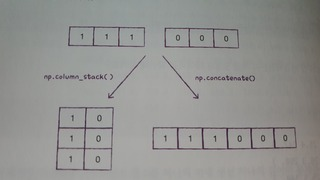

In [5]:
fish_target = np.concatenate((np.ones(35), np.zeros(14)))
# np.concatenate 함수는 첫 번째 차원을 따라 배열을 연결한다.
# np.column_stack()은 열로 붙인다.
print(fish_target)
print(fish_target.shape)

[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0.]
(49,)


In [27]:
from sklearn.model_selection import train_test_split
# 앞 장에서는 np함수를 이용해 시드값을 부여하고 랜덤한 인덱스들을 추렸지만,
# 싸이킷 런에서는 유틸리티 함수로 훈련셋과 검증셋을 분리할 수 있다.

train_input, test_input, train_target, test_target = train_test_split(fish_data, fish_target, random_state=42)

print(train_target.shape)
print(test_target.shape)

(36,)
(13,)


In [8]:
from sklearn.neighbors import KNeighborsClassifier
model = KNeighborsClassifier()
model.fit(train_input, train_target)
model.score(test_input, test_target)

1.0

In [9]:
print(model.predict([[25, 150]]))
# 0은 빙어, 1은 도미.
# 아래는 도미라고 생각했던 데이터인데 빙어로 분류된 결과. 왜 이런 결과가 나왔을까?

[0.]


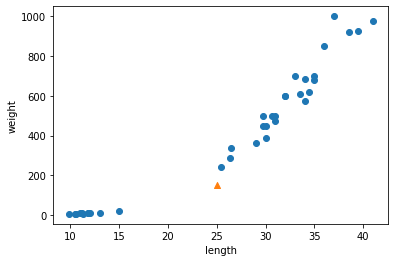

In [11]:
import matplotlib.pyplot as plt

plt.scatter(train_input[:,0], train_input[:, 1])
plt.scatter(25, 150, marker='^')
plt.xlabel('length')
plt.ylabel('weight')
plt.show()

[[ 92.00086956 130.48375378 138.32150953 140.00603558 140.62090883]] [[12 29  5 19  4]]


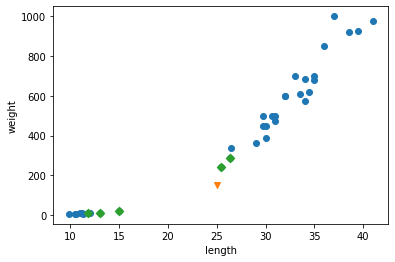

In [19]:
# k-최근접 이웃은 
# 주변의 샘플 중에서 다수인 클래스를 예측결과로 발표한다.

# KNeighborsClassifier 클래스는 주어진 샘플에서 가장 가까운 이웃을 찾아주는 'kneighbors()'메서드를 제공한다.
# 이 메서드는 이웃까지의 거리와 이웃 샘플의 인덱스를 반환한다.

# KNeighborsClassifier클래스의 n_neighbors 기본값은 5이므로 5개의 이웃이 반환된다.

distances, indexes = model.kneighbors([[25, 150]])
print(distances, indexes)

plt.scatter(train_input[:,0], train_input[:,1])
plt.scatter(25, 150, marker='v')
plt.scatter(train_input[indexes, 0], train_input[indexes, 1], marker = 'D')
plt.xlabel('length')
plt.ylabel('weight')
plt.show()

In [22]:
print(train_input[indexes])
print(train_target[indexes])
# 빙어(0)가 더 많아서 빙어로 분류한 것임.

[[[ 25.4 242. ]
  [ 15.   19.9]
  [ 13.   12.2]
  [ 26.3 290. ]
  [ 11.8  10. ]]]
[[1. 0. 0. 1. 0.]]


# 데이터 전처리

길이 (0-40) 와 무게 (0-1000)는 서로다른 단위를 갖는 특성으로, K-이웃 최근접 알고리즘의 분류 기준인 '거리'에 동등하게 영향을 미치지 않는다.

> 이를 두 특성의 '스케일(scale)'이 다르다고 표현한다.

데이터를 표현하는 기준이 다르면 알고리즘이 올바르게 예측할 수 없다. 알고리즘이 거리기반일 때 특히 더 그렇다. **특성값들을 일정한 기준으로 맞춰 주어야 하는데, 이를 데이터 전처리 (Data preprocessing)** 이라고 한다.

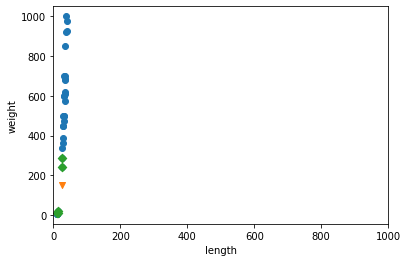

In [23]:
# matplotlib에서 한 축 범위를 지정하려면 xlim 또는 ylim 함수를 사용하면 된다.
plt.scatter(train_input[:,0], train_input[:,1])
plt.scatter(25, 150, marker='v')
plt.scatter(train_input[indexes,0], train_input[indexes,1], marker='D')
plt.xlim((0,1000))
plt.xlabel('length')
plt.ylabel('weight')
plt.show()

# 표준 점수

위처럼 길이는 무게에 비해 생선의 거리에 큰 영향을 주진 않는 특성이다.
> 가장 널리 사용하는 전처리 방법 중 하나는 **'표준 점수(z점수)'**이다.

표준점수는 각 특성값이 0에서 표준편차의 몇 배만큼 벌어져 있는지를 나타낸다. 이를 통해 특성값의 크기와 상관없이 동일한 조건으로 비교할 수 있다.

> 분산은 데이터에서 평균을 뺀 값을 모두 제곱한 다음, 평균을 내어 구한다.

> 표준편차는 분산의 제곱근으로 데이터가 분산된 정도를 나타낸다.

> 표준점수는 각 데이터가 원점에서 몇 표준편차만큼 떨어져 있는지를 나타내는 값이다.

표준점수는 평균을 뺴고 표준편차로 나누어주면 된다.

```
mean = np.mean(train_input, axis=0)
std = np.std(train_input, axis=0)
# axis=0 (행을 따라 계산)로 설정해 각 특성별로 평균과 표준편차를 계산해야함.
```

In [24]:
mean = np.mean(train_input, axis=0)
std = np.std(train_input, axis=0)
print(mean)
print(std)

[ 26.175      418.08888889]
[ 10.21073441 321.67847023]


In [29]:
# 각 특성마다 평균과 표준편차를 계산했다.
# 이제 원본 데이터에서 평균을 빼고 표준편차로 나누어 표준점수로 변환하자.

train_scaled = (train_input - mean) / std

# 브로드캐스팅 (Broadcasting)

위 코드블럭에서 train_input은 (36, 2) shape이고, mean과 std는 각각 (2,), (2,)이다. 넘파이는 똑똑하게도 모든 행에 대해 사칙연산을 피연산자인 mean, std같은 값으로 계산해주는 기능이 있다. 아래 그림을 참고하자.

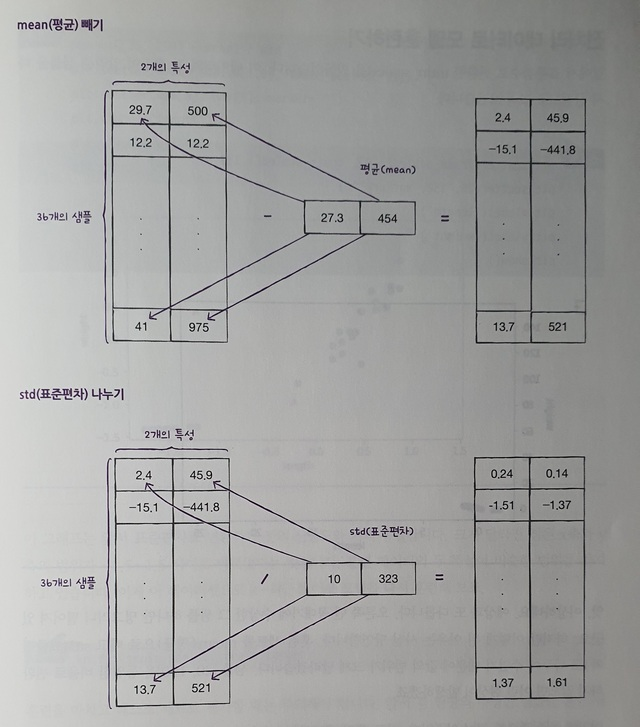

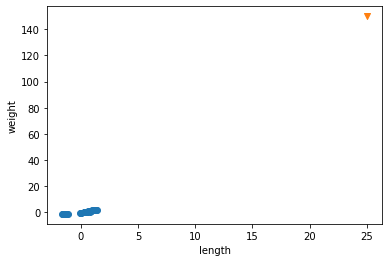

In [32]:
# 자, 이제 다시 train_scaled로 학습해보자.

plt.scatter(train_scaled[:,0], train_scaled[:,1])
plt.scatter(25, 150, marker='v')
plt.xlabel('length')
plt.ylabel('weight')
plt.show()

> 위 [[25, 150]]라는 확인용 데이터는 데이터 전처리된 학습 데이터들과 스케일이 다르므로, 저렇게 붕뜬 형태로 보이는게 당연하다.

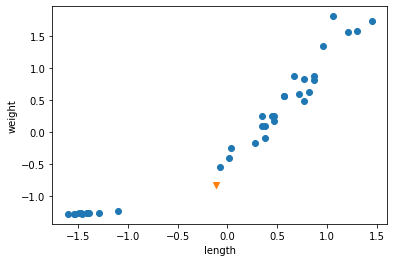

In [33]:
new = ([25, 150] - mean) / std
plt.scatter(train_scaled[:,0], train_scaled[:,1])
plt.scatter(new[0], new[1], marker='v')
plt.xlabel('length')
plt.ylabel('weight')
plt.show()

> 데이터전처리를 하기 전의 산점도와 비슷한 형태지만, 두 특성의 범위가 -1.5에서 1.5 사이로 바뀌었다. 훈련 데이터의 두 특성이 비슷한 범위를 차지한다.

In [40]:
model.fit(train_scaled, train_target)

#mean_test = np.mean(test_input, axis=0) -> 테스트 세트도 훈련 세트의 평균/표준편차로 동일하게 처리해줘야 한다.
#std_test = np.std(test_input, axis=0)   -|  

test_scaled = (test_input - mean) / std
#test_scaled = (test_input - mean_test) / std_test -> 테스트 세트도 훈련 세트의 평균/표준편차로 동일하게 처리해줘야 한다.

In [41]:
model.score(test_scaled, test_target)

1.0

In [42]:
model.predict([new])
# 도미 (1)로 분류함.

array([1.])

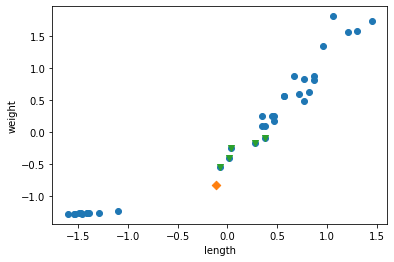

In [43]:
distances, indexes = model.kneighbors([new])
plt.scatter(train_scaled[:,0], train_scaled[:,1])
plt.scatter(new[0], new[1], marker='D')
plt.scatter(train_scaled[indexes,0], train_scaled[indexes,1],marker='v')
plt.xlabel('length')
plt.ylabel('weight')
plt.show()

# 2.2장 데이터 전처리 정리

> 머신러닝 알고리즘은 학습데이터의 특성들의 스케일이 다를 때 잘 작동하지 않는다.

> 데이터 전처리에는 많은 방법이 있지만, 대부분의 경우 이 장에서 다뤄본 '표준점수' 방법을 사용한다.

> 데이터를 전처리할 때 주의할 점은 훈련 세트를 변환한 방식 그대로 테스트 세트를 변환해야 한다는 것이다.




---
**이번 장 키워드**

1.   **데이터 전처리**는 머신러닝 모델에 훈련 데이터를 주입하기 전에 훈련 데이터를 가공하는 단계를 말한다.
2.   **표준점수**는 훈련 세트의 스케일을 바꾸는 대표적인 방법 중 하나이다. 표준점수를 얻으려면 특성별로 특성의 평균을 빼고 표준편차로 나눈다. **반드시 훈련 세트의 평균과 표준편차로 테스트 세트의 스케일을 바꿔주어야 한다.**
3.   **브로드캐스팅**은 크기가 다른 numpy 배열에서 자동으로 사칙 연산을 모든 행이나 열로 확장하여 수행하는 기능이다.
---
sklearn.model_selection의 train_test_split 함수
```
from sklearn.model_selection import train_test_split
train_input, test_input, train_target, test_target = np.train_test_split(fish_data, fish_target, random_state=난수값)
```
훈련 데이터를 훈련 세트와 테스트 세트로 나누는 함수이다. test_size 매개변수로 테스트 세트로 나눌 비율을 정할 수 있으며, 기본은 0.25 (25%)이다. 또, shuffle 매개변수로 훈련 세트와 테스트 세트로 나누기 전에 무작위로 섞을지 여부를 결정할 수 있다. 기본값은 True이며, stratify 매개변수에 클래스 레이블이 담긴 배열(타겟 데이터)을 전달하면 클래스 비율에 맞게 훈련 세트와 테스트 세트를 나눈다.

```
from sklearn.neighbors import KNeighborsClassifier
model = KNeighborsClassifier()
model.fit(train_scaled, train_target)

# 길이,무게가 전처리된 샘플이 n_neighbors 매개변수만큼의 가까운 샘플들에 대한 거리와 인덱스 정보 반환
scaled_sample = ([25, 150] - mean) / std
distances, indices = model.kneighbors([scaled_sample])
```
kneighbors() 는 k-최근접 이웃 객체(KNeighborsClassifier)의 메서드이다. 이 메서드는 입력한 데이터에 가장 가까운 이웃을 찾아 1)거리와 2)이웃샘플의 인덱스를 반환한다. 기본적으로 이웃의 갯수는 클래스의 객체를 생성할 때 지정한 개수를 사용하며, n_neighbors 매개변수로 다르게 지정할 수도 있다. return_distance 매개변수를 False로 지정하면 이웃 샘플의 인덱스만 반환하고 거리를 반환시키지 않을 수도 있다. 이 매개변수의 기본값은 True이다.



